## MSA code

In this notebook an example of this code applied to contacat prediction for proteins is given. First the MSA is transformed into a Potts array and L2 regularized PLE is used to extract the couplings. Finally the Frobenius norm corrected with apc is used find the predicted contacts.

The data is obtained from Pfam, the protein contact prediction pipeline from Ekeberg et al. 2013 is followed, where APC was introduced by Dunn et al. 2008.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from spininfer.data.MSA import potts_dataset_from_msa
from spininfer.objectives.PLE_potts import PlePottsObjective
from spininfer.fitters.lbfgs_fitter import LbfgsFitter
from spininfer.objectives.regularization import L2Regularizer
from spininfer.objectives.regularized import RegularizedObjective
from spininfer.analysis.contacts import contact_scores

# With numba it can take around 40 minutes to run the full code and with jax 30 seconds
model, dataset = potts_dataset_from_msa("PF00014.alignment.full.gz", fmt="stockholm", backend="numba")
print("Dataset has been loaded")

objective = PlePottsObjective()
regularizer = L2Regularizer()
regularized_obj = RegularizedObjective(objective, regularizer)
fitter = LbfgsFitter(model, regularized_obj, dataset)
result = fitter.fit()
h, J = result.h, result.J
contacs = contact_scores(model, J)

Dataset has been loaded


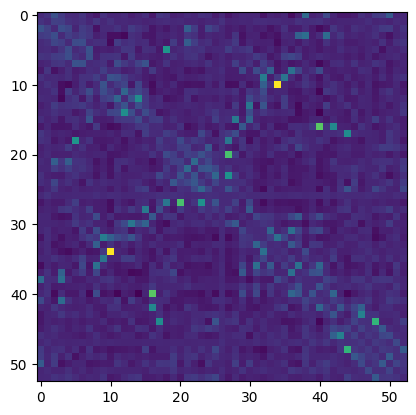

In [2]:
plt.imshow(contacs)
plt.show()

In this code it can be seen that we find multiple spots with a high score. The highest spots align with conserved disulfide bonds.